In [18]:
import pandas as pd
import numpy as np

from analysis_src.data_inspaction import BasicDataInspection, StatisticsInspection, MissingValuesInspection, DataTypesInspection, DataInspector, DataInspection
from analysis_src.bivariate_analysis import BivariateAnalyzer,NumericalVsNumericalAnalysis, CategoricalVsNumericalAnalysis
from analysis_src.univariate_analysis import UnivariateAnalyzer, NumericalUnivariateAnalysis, CategoricalUnivariateAnalysis
from analysis_src.missing_values_analysis import SimpleMissingValuesAnalysis
from analysis_src.multivariate_analysis import SimpleMultivariateAnalysis


# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [2]:
data_path = '../data/laptop_data.csv'
df = pd.read_csv(data_path)

In [3]:
data_inspector = DataInspector(DataTypesInspection())
data_inspector.inspect(df)


Data Types and Non-null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6693 entries, 0 to 6692
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          6693 non-null   object 
 1   brand         6693 non-null   object 
 2   os            6693 non-null   object 
 3   cpu_cores     6693 non-null   float64
 4   cpu_threads   6693 non-null   float64
 5   gpu_vram      6693 non-null   float64
 6   ram_capacity  6693 non-null   float64
 7   ram_ddr_type  6693 non-null   object 
 8   hdd           6693 non-null   int64  
 9   ssd           6693 non-null   int64  
 10  screen_size   6693 non-null   float64
 11  screen_res    6693 non-null   object 
 12  touchscreen   6693 non-null   int64  
 13  user_rating   6693 non-null   float64
 14  price         6693 non-null   float64
 15  cpu           6693 non-null   object 
 16  gpu           6693 non-null   object 
dtypes: float64(7), int64(3), object(7)
mem

In [4]:
data_inspector.set_strategy(StatisticsInspection())
data_inspector.inspect(df)


Summary Statistics (Numerical Features):
         cpu_cores  cpu_threads     gpu_vram  ram_capacity          hdd  \
count  6693.000000  6693.000000  6693.000000   6693.000000  6693.000000   
mean      6.687733    10.877484     1.916181     12.368445   186.107276   
std       4.362794     6.055575     3.095897      8.055429   384.489169   
min       2.000000     2.000000     0.000000      2.000000     0.000000   
25%       4.000000     8.000000     0.000000      8.000000     0.000000   
50%       6.000000     8.000000     0.000000      8.000000     0.000000   
75%      10.000000    16.000000     4.000000     16.000000     0.000000   
max      24.000000    48.000000    24.000000    196.000000  2048.000000   

               ssd  screen_size  touchscreen  user_rating          price  
count  6693.000000  6693.000000  6693.000000  6693.000000    6693.000000  
mean    503.512027    15.007777     0.106679     4.334835   79770.884431  
std     396.367157     1.101791     0.308727     0.303348


Missing Values Count by Column:
Series([], dtype: int64)

Visualizing Missing Values...


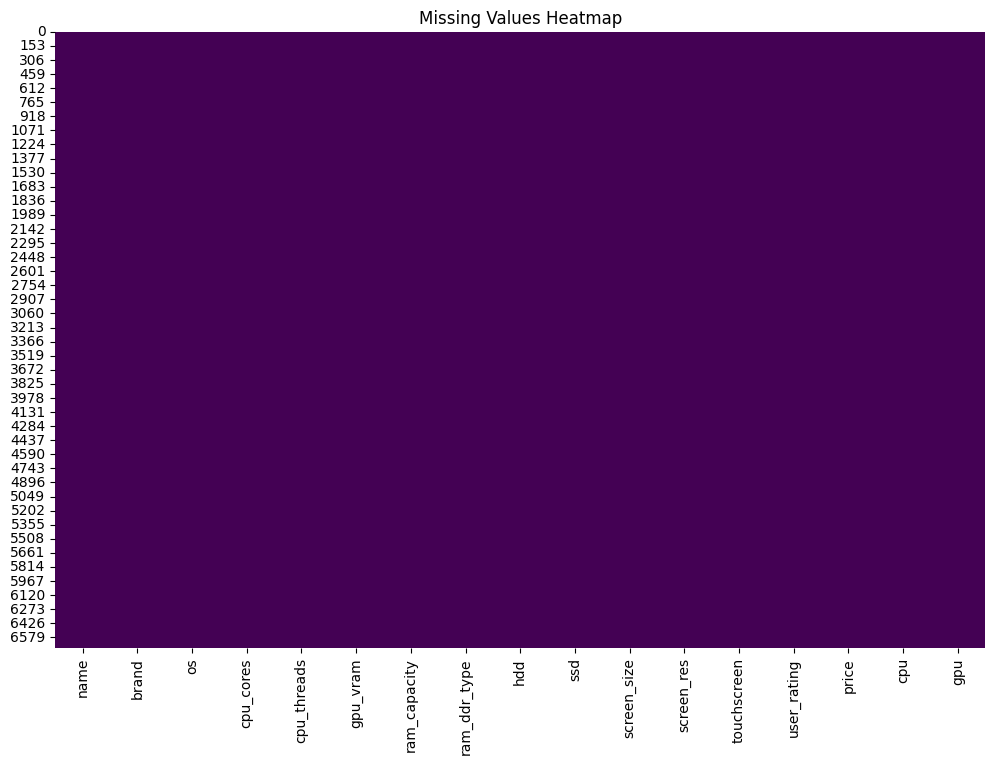

In [5]:
# 2: Missing Values Analysis
missing_values_analyzer = SimpleMissingValuesAnalysis()
missing_values_analyzer.analyze(df)

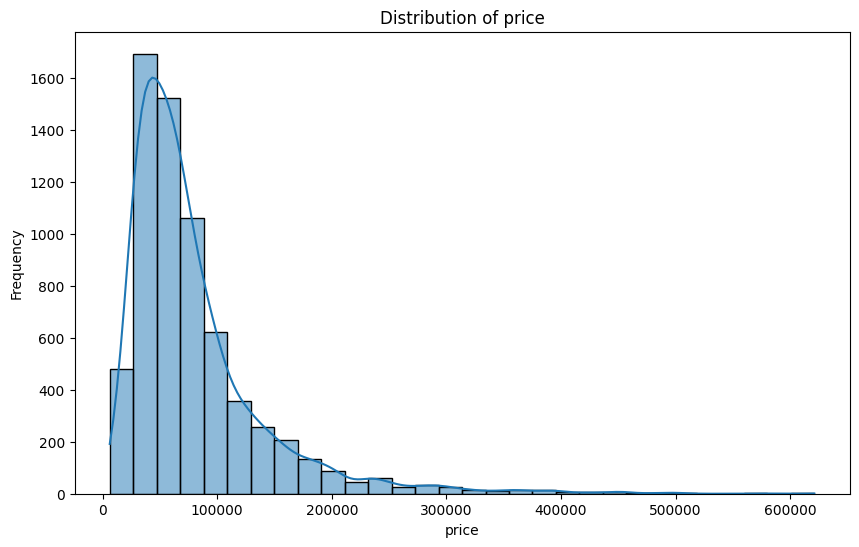

In [6]:
# 3: Univariate Analysis
univariate_analyzer = UnivariateAnalyzer(NumericalUnivariateAnalysis())
univariate_analyzer.execute_analysis(df, 'price')

/home/johnmoew/hour/Project/ML/rec_system/analysis/analysis_src/univariate_analysis.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette="muted")


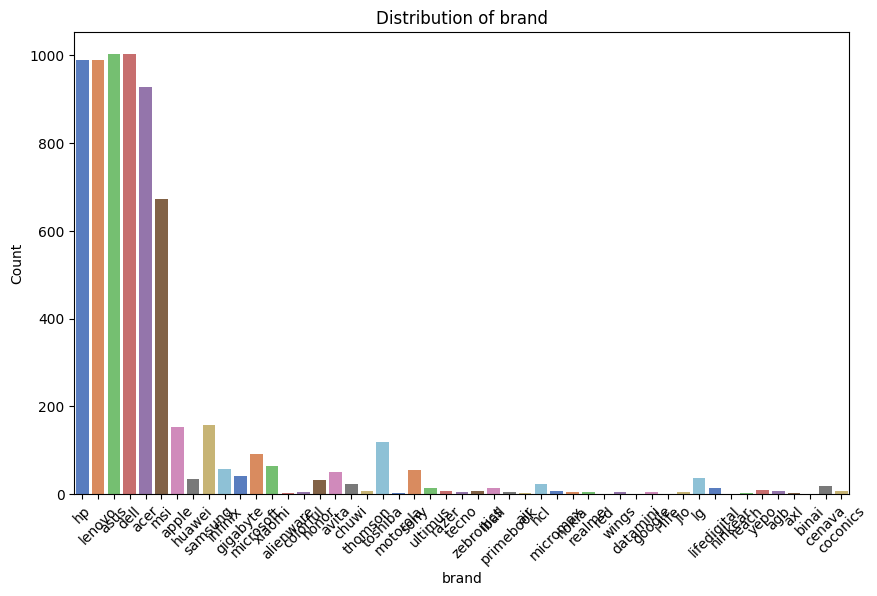

In [9]:
# Analyzing a Categorical Feature
univariate_analyzer.set_strategy(CategoricalUnivariateAnalysis())
univariate_analyzer.execute_analysis(df, 'brand')

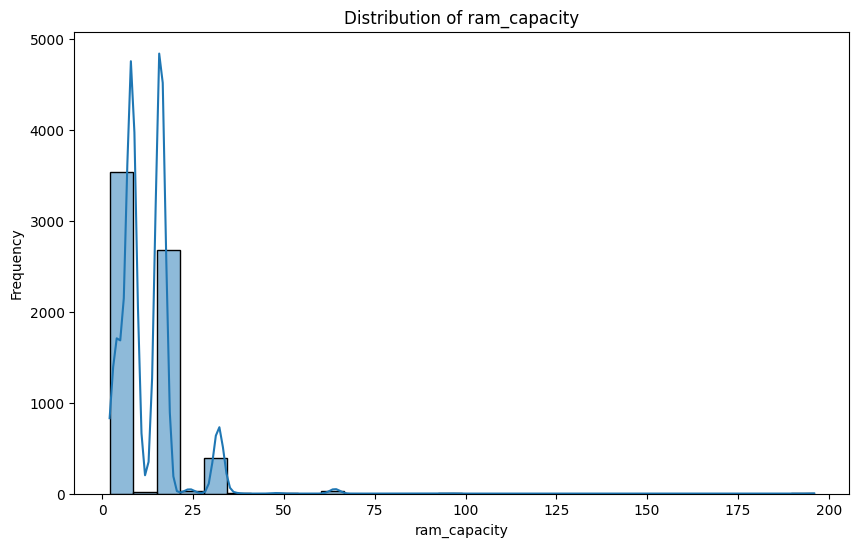

In [10]:
univariate_analyzer.set_strategy(NumericalUnivariateAnalysis())
univariate_analyzer.execute_analysis(df, 'ram_capacity')

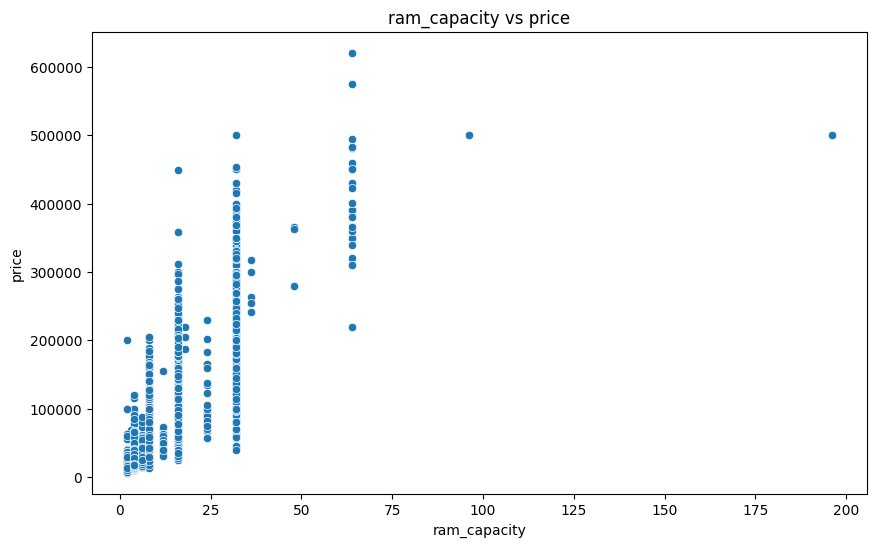

In [12]:
analyzer = BivariateAnalyzer(NumericalVsNumericalAnalysis())
analyzer.execute_analysis(df, "ram_capacity", "price")


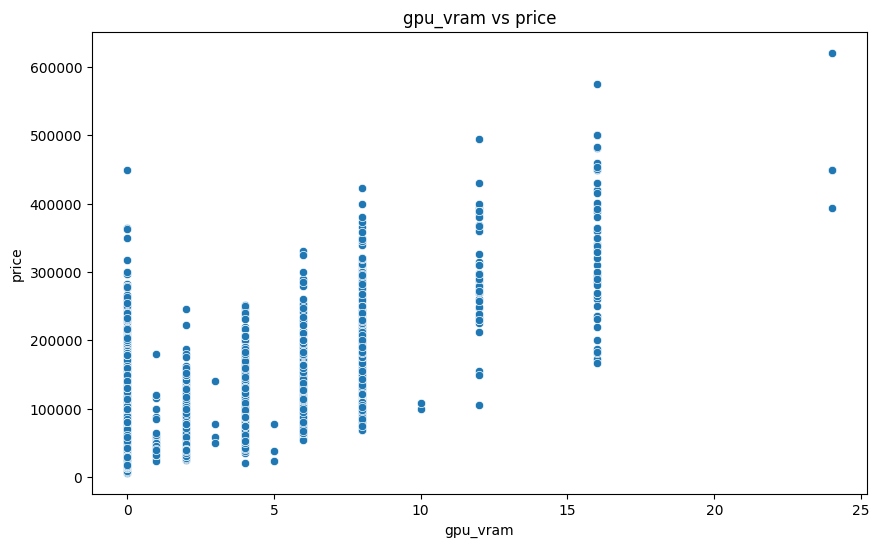

In [13]:
analyzer.execute_analysis(df, "gpu_vram", "price")


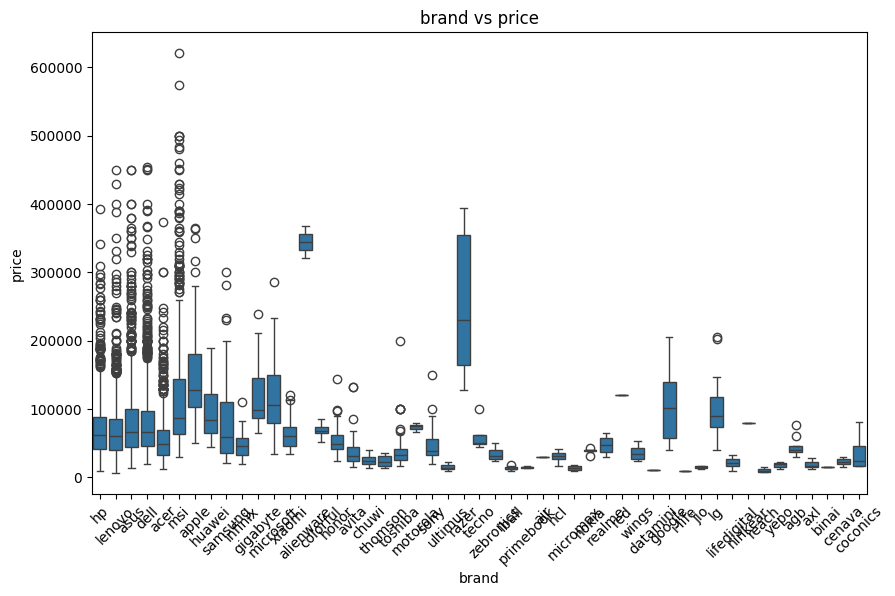

In [14]:
analyzer.set_strategy(CategoricalVsNumericalAnalysis())
analyzer.execute_analysis(df, "brand", "price")


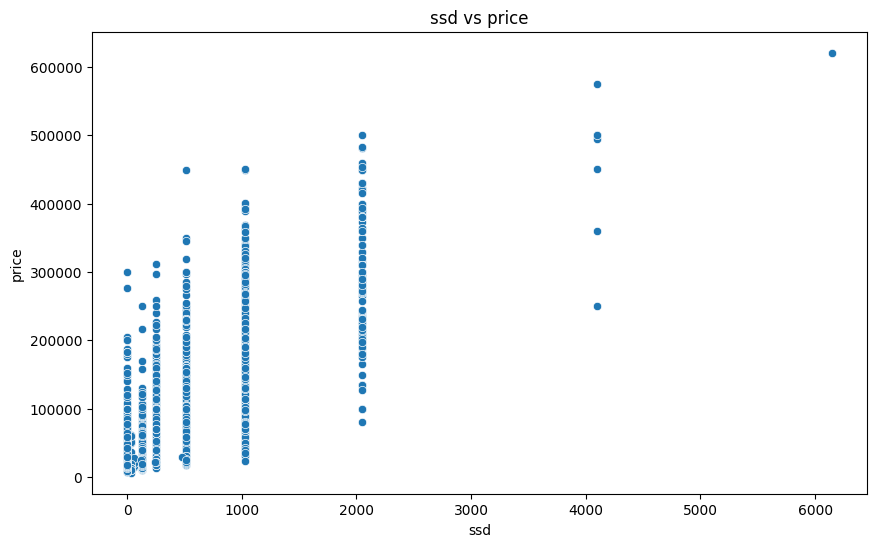

In [16]:
analyzer.set_strategy(NumericalVsNumericalAnalysis())
analyzer.execute_analysis(df, "ssd", "price")


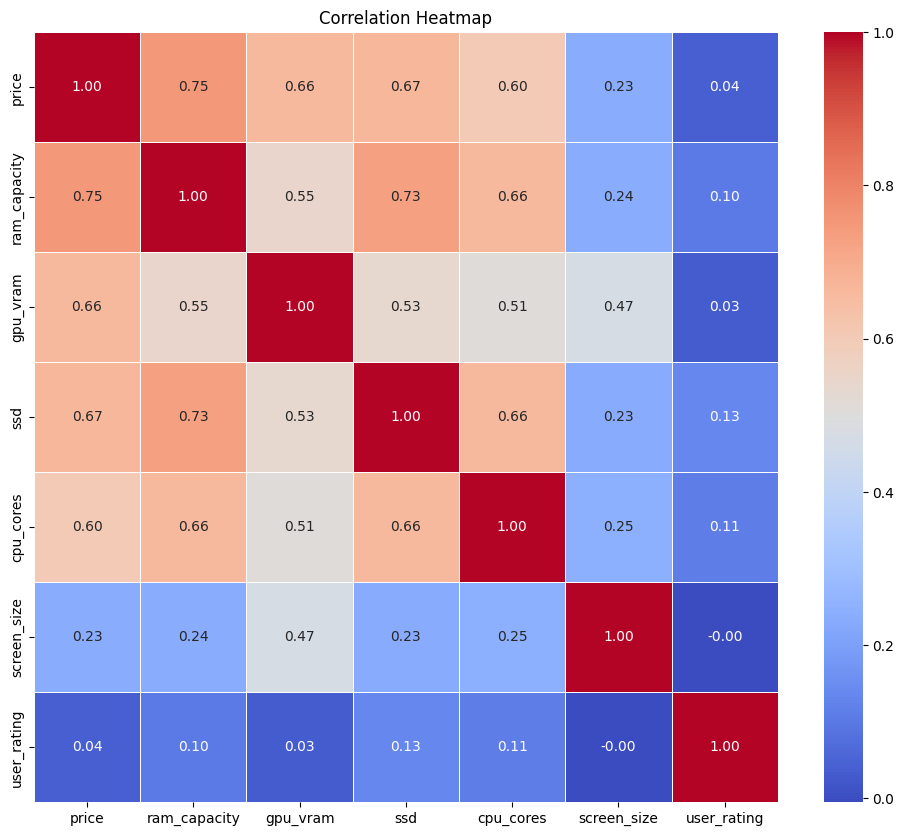

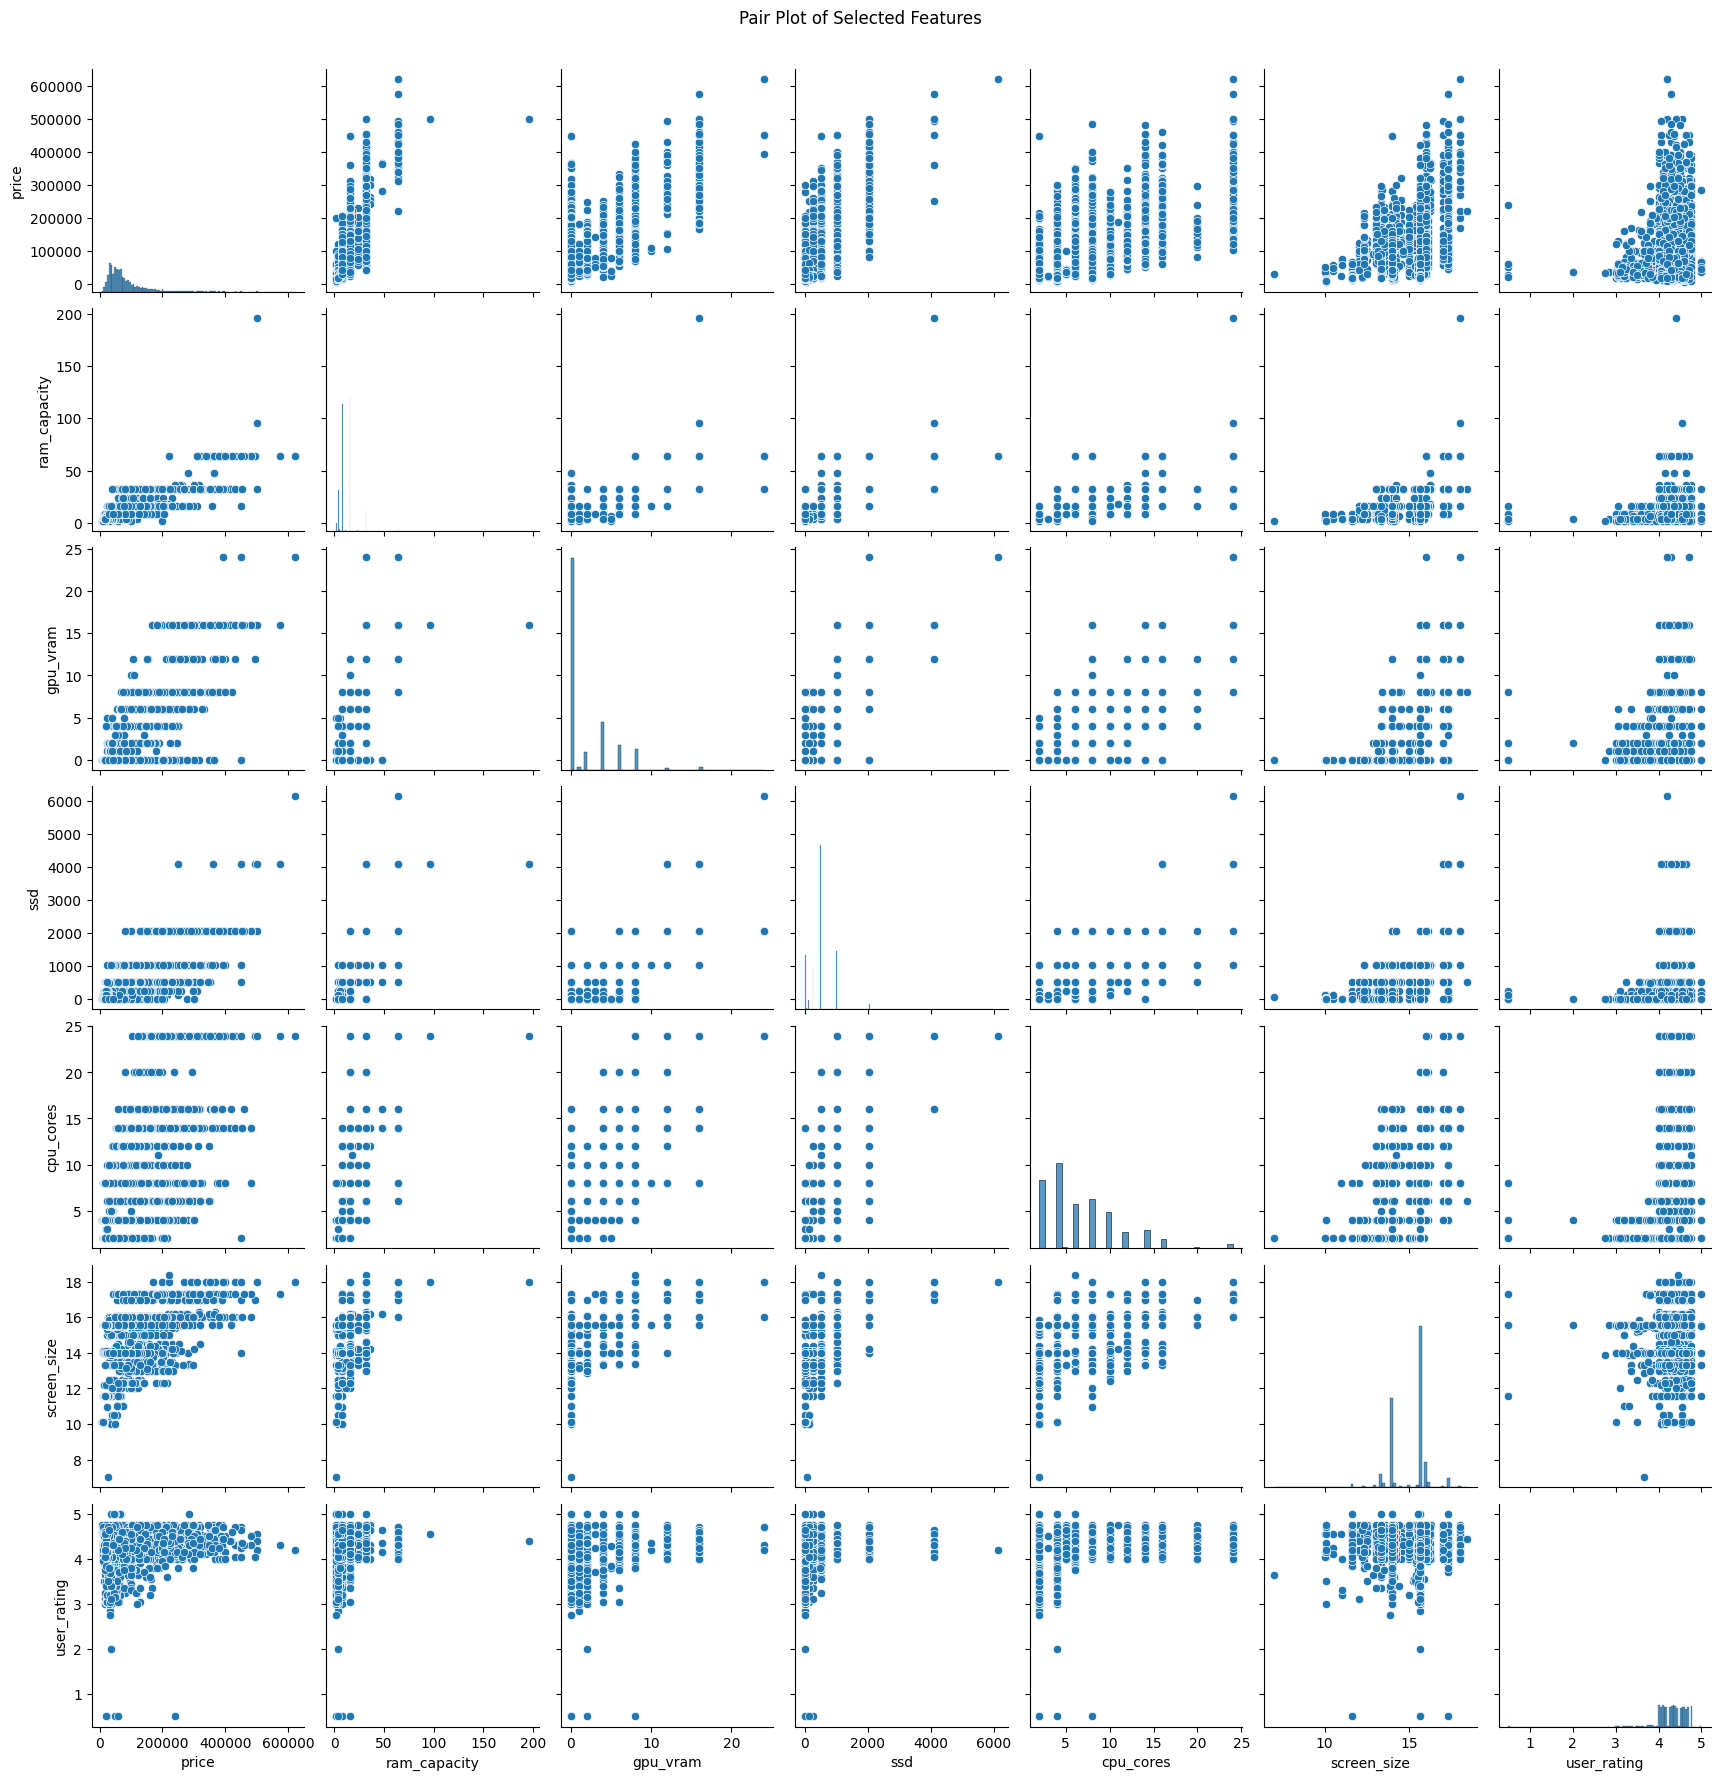

In [19]:
selected = df[
    [
        "price",
        "ram_capacity",
        "gpu_vram",
        "ssd",
        "cpu_cores",
        "screen_size",
        "user_rating"
    ]
]

multivariate_analyzer = SimpleMultivariateAnalysis()
multivariate_analyzer.analyze(selected)
